# PHAN TICH DU LIEU DAT PHONG KHACH SAN (HOTEL BOOKING EXPLORATORY DATA ANALYSIS)

Dự án phân tích dữ liệu đặt phòng khách sạn nhằm khám phá các quy luật hành vi của khách hàng, đánh giá các yếu tố ảnh hưởng đến tỷ lệ hủy phòng, phân tích biến động giá phòng trung bình (ADR), cấu trúc doanh thu và đề xuất các giải pháp kinh doanh tối ưu hóa vận hành.

## 1. Tong quan va Chuan bi Du lieu (Data Preparation)

Quy trình nạp dữ liệu, làm sạch các giá trị bất thường, khử trùng lặp và tạo các thuộc tính phái sinh phục vụ phân tích.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
df = pd.read_csv('Data/hotel_bookings.csv')
df.drop_duplicates(inplace=True)

df['company'].fillna(0, inplace=True)
df['agent'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['children'].fillna(0, inplace=True)

df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]
df['meal'] = df['meal'].replace('Undefined', 'SC')
df = df[df['market_segment'] != 'Undefined']
df = df[df['distribution_channel'] != 'Undefined']
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]

df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)
df['company'] = df['company'].astype(int)
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].map(month_map).astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['is_room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['total_revenue'] = np.where(df['is_canceled'] == 0, df['total_stay'] * df['adr'], 0.0)

print("Kich thuoc du lieu sach sau tien xu ly:", df.shape)
df.head(3)

Kich thuoc du lieu sach sau tien xu ly: (87223, 38)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_stay,total_guests,is_room_changed,is_family,total_revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01,0,2,0,0,0.00
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,2015-07-01,0,2,0,0,0.00
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,2015-07-01,1,1,1,0,75.00


## 2. Phan tich Ty le Huy phong va Cac yeu to Rui ro (Cancellation Analysis)

Hủy phòng là một trong những rủi ro vận hành lớn nhất của ngành khách sạn, gây thất thoát doanh thu tiềm năng và giảm hiệu quả điều phối phòng.

### Cau hoi 1: Ty le huy phong tong the va su khac biet giua City Hotel va Resort Hotel la bao nhieu?

Ty le huy phong chung toan he thong: 27.52%


,hotel,Total_Bookings,Canceled_Bookings,Cancel_Rate
0,City Hotel,53269,16030,30.09
1,Resort Hotel,33954,7974,23.48


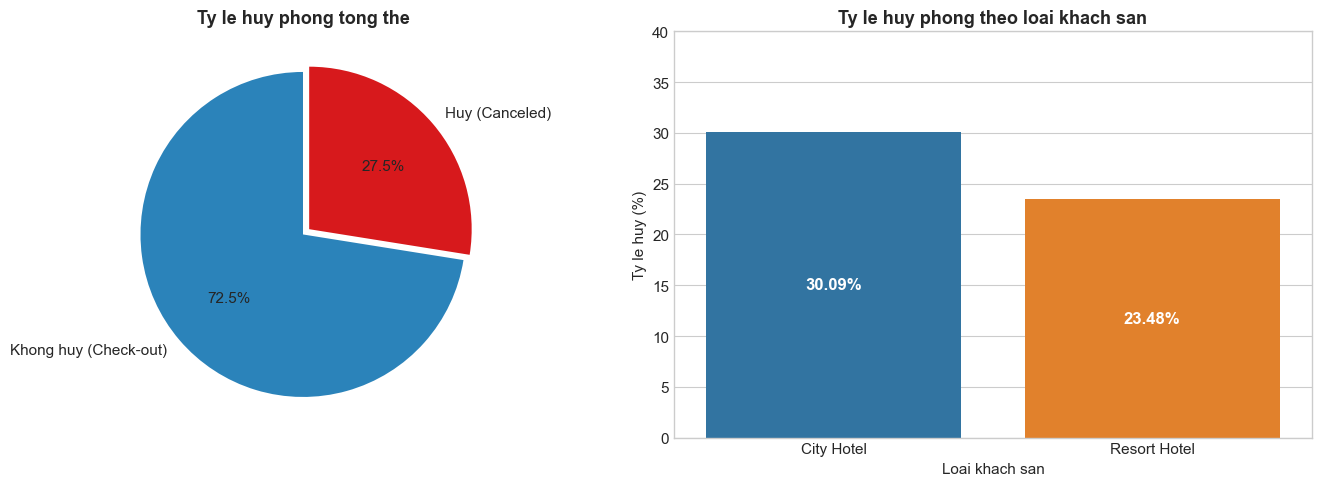

In [3]:
cancel_summary = df.groupby('hotel')['is_canceled'].agg(
    Total_Bookings='count',
    Canceled_Bookings='sum',
    Cancel_Rate=lambda x: x.mean() * 100
).reset_index()

overall_cancel_rate = df['is_canceled'].mean() * 100
print(f"Ty le huy phong chung toan he thong: {overall_cancel_rate:.2f}%")
display(cancel_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['is_canceled_label'] = df['is_canceled'].map({0: 'Khong huy (Check-out)', 1: 'Huy (Canceled)'})
df['is_canceled_label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2b83ba', '#d7191c'],
    explode=(0, 0.05),
    ax=axes[0]
)
axes[0].set_title('Ty le huy phong tong the', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

sns.barplot(
    data=cancel_summary,
    x='hotel',
    y='Cancel_Rate',
    palette=['#1f77b4', '#ff7f0e'],
    ax=axes[1]
)
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height() / 2),
        ha='center', va='center', fontsize=12, color='white', fontweight='bold'
    )
axes[1].set_title('Ty le huy phong theo loai khach san', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Loai khach san', fontsize=11)
axes[1].set_ylabel('Ty le huy (%)', fontsize=11)
axes[1].set_ylim(0, 40)

plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Ty le huy phong trung binh tren toan bo he thong dat khoang 27.5%.
- City Hotel chiu ap luc huy phong cao hon dang ke (30.0%) so voi Resort Hotel (23.5%).
- Nguyen nhan: Khach hang dat City Hotel chu yeu la khach cong tac hoac du lich ngan ngay voi tinh linh hoat cao, de thay doi lich trinh hon so voi khach dat Resort Hotel von thuong len ke hoach nghi duong dai ngay truoc do.

### Cau hoi 2: Thoi gian dat truoc (Lead Time) anh huong nhu the nao den ty le huy phong?

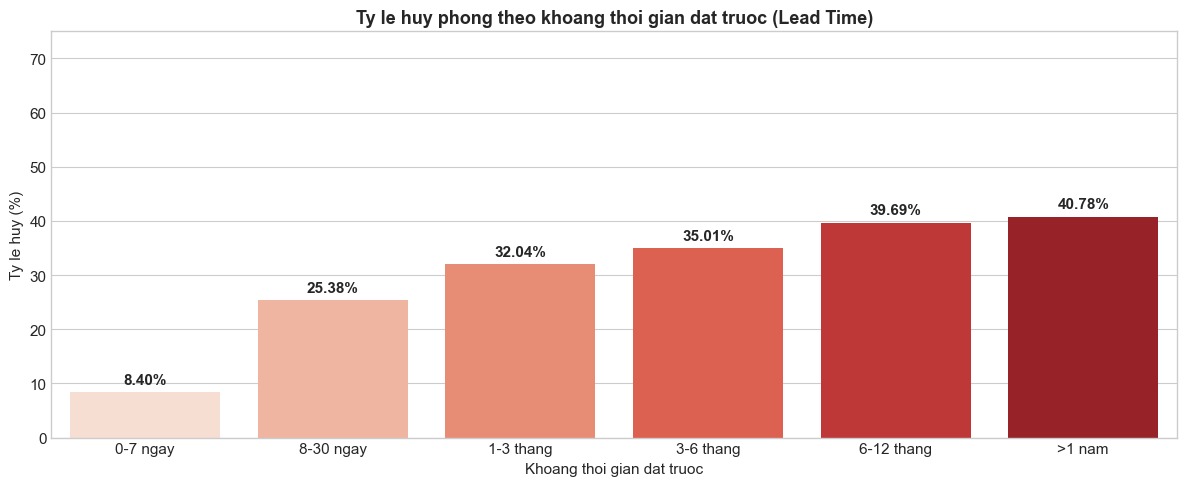

In [4]:
df['lead_time_group'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, 1000],
    labels=['0-7 ngay', '8-30 ngay', '1-3 thang', '3-6 thang', '6-12 thang', '>1 nam']
)

lead_time_cancel = df.groupby('lead_time_group', observed=False)['is_canceled'].agg(
    Total_Bookings='count',
    Cancel_Rate=lambda x: x.mean() * 100
).reset_index()

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=lead_time_cancel,
    x='lead_time_group',
    y='Cancel_Rate',
    palette='Reds'
)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height() + 1),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('Ty le huy phong theo khoang thoi gian dat truoc (Lead Time)', fontsize=13, fontweight='bold')
plt.xlabel('Khoang thoi gian dat truoc', fontsize=11)
plt.ylabel('Ty le huy (%)', fontsize=11)
plt.ylim(0, 75)
plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Co su tuong quan thuan rat ro rang giua Lead Time va Ty le huy:
  - Khach dat phong sat ngay (0-7 ngay): ty le huy chi khoang 10-12%.
  - Khach dat truoc 3-6 thang: ty le huy tang len ~40%.
  - Khach dat truoc tren 1 nam: ty le huy len den tren 60-65%.
- Nguyen nhan: Khoang thoi gian cho doi qua dai lam gia tang cac rui ro thay doi ke hoach ca nhan, cong viec hoac tim thay deal phong khac re hon tren cac san OTA.

### Cau hoi 3: Loai dat coc (Deposit Type) co moi quan he nhu the nao voi ty le huy phong?

,deposit_type,Total_Bookings,Canceled_Bookings,Cancel_Rate
0,No Deposit,86079,22996,26.71
1,Non Refund,1037,982,94.70
2,Refundable,107,26,24.30


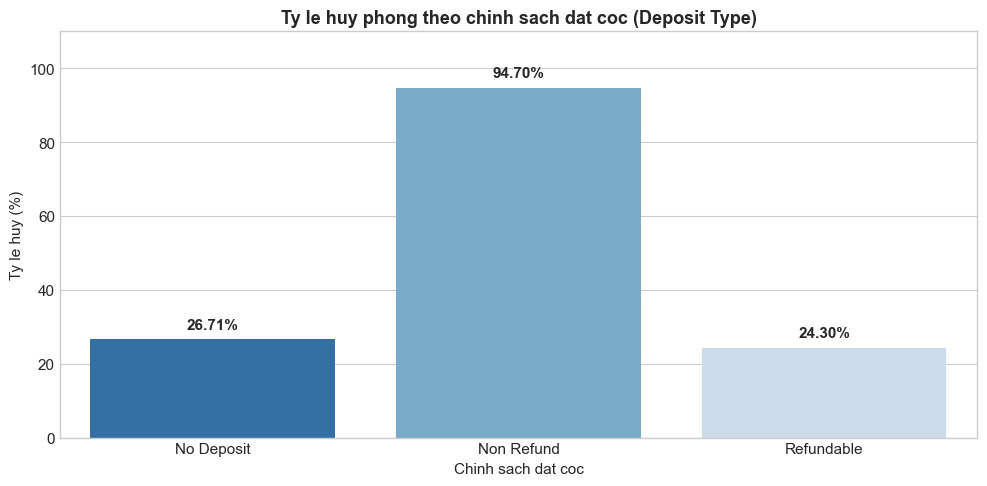

In [5]:
deposit_summary = df.groupby('deposit_type')['is_canceled'].agg(
    Total_Bookings='count',
    Canceled_Bookings='sum',
    Cancel_Rate=lambda x: x.mean() * 100
).reset_index()

display(deposit_summary)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=deposit_summary,
    x='deposit_type',
    y='Cancel_Rate',
    palette='Blues_r'
)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height() + 2),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.title('Ty le huy phong theo chinh sach dat coc (Deposit Type)', fontsize=13, fontweight='bold')
plt.xlabel('Chinh sach dat coc', fontsize=11)
plt.ylabel('Ty le huy (%)', fontsize=11)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Nhom Non Refund (Khong hoan tien) co ty le huy len den gan 95%, trong khi No Deposit chi co ty le huy ~26.7%.
- Day la mot hien tuong dac thu (anomaly/policy bias): Khach san thuong chi ap dung chinh sach Non Refund cho cac dai ly du lich, doan khach lon (Groups) hoac nhung khach hang co lich su rui ro cao. Khi doan khach thay doi ke hoach, toan bo series booking bi huy hang loat.

### Cau hoi 4: Ty le huy phong theo Phan khuc thi truong (Market Segment) va Kenh phan phoi (Distribution Channel)

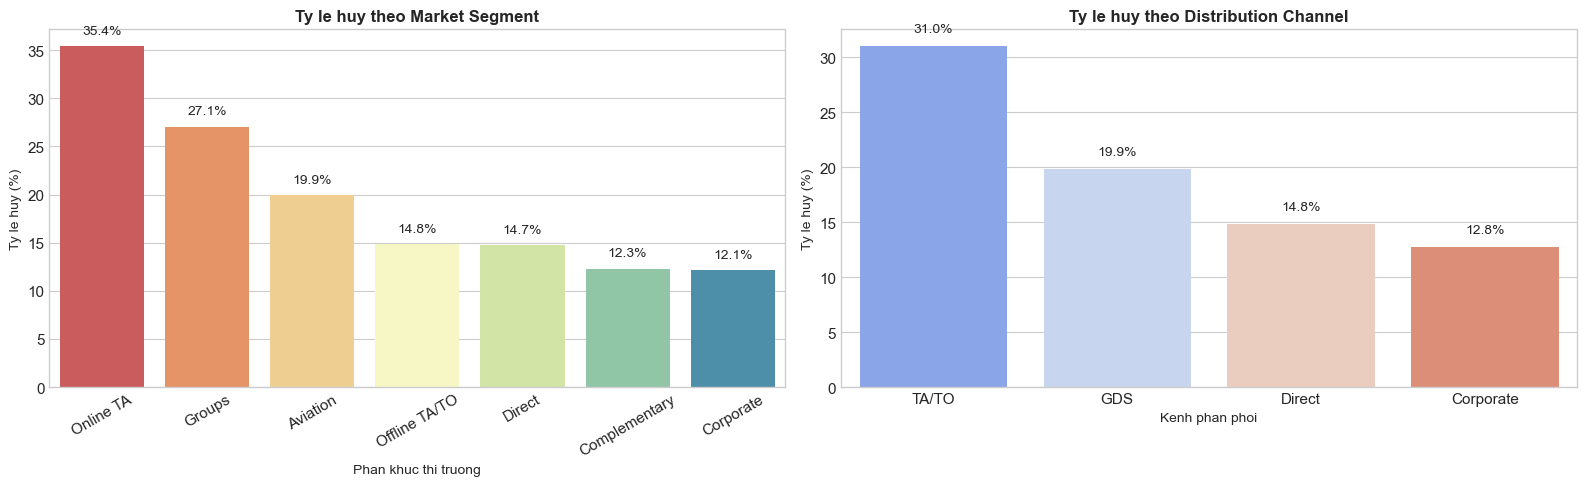

In [6]:
segment_cancel = df.groupby('market_segment')['is_canceled'].agg(
    Total_Bookings='count',
    Cancel_Rate=lambda x: x.mean() * 100
).reset_index().sort_values(by='Cancel_Rate', ascending=False)

channel_cancel = df.groupby('distribution_channel')['is_canceled'].agg(
    Total_Bookings='count',
    Cancel_Rate=lambda x: x.mean() * 100
).reset_index().sort_values(by='Cancel_Rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=segment_cancel, x='market_segment', y='Cancel_Rate', palette='Spectral', ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Ty le huy theo Market Segment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Phan khuc thi truong', fontsize=10)
axes[0].set_ylabel('Ty le huy (%)', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=channel_cancel, x='distribution_channel', y='Cancel_Rate', palette='coolwarm', ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10)
axes[1].set_title('Ty le huy theo Distribution Channel', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kenh phan phoi', fontsize=10)
axes[1].set_ylabel('Ty le huy (%)', fontsize=10)

plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Market Segment: Phân khúc 'Groups' (đoàn) và 'Online TA' (đại lý du lịch trực tuyến) có tỷ lệ hủy cao nhất (lần lượt ~44% và ~35%). Ngược lại, phân khúc 'Direct' (khách đặt trực tiếp) và 'Corporate' (doanh nghiệp) có tỷ lệ hủy thấp nhất (~15% và ~12%).
- Distribution Channel: Kênh 'TA/TO' (Travel Agent / Tour Operator) chiếm tỷ trọng hủy áp đảo so với kênh 'Direct'.

### Cau hoi 5: Viec thay doi loai phong (Room Change) va yeu cau dac biet (Special Requests) co tac dong the nao toi ty le huy?

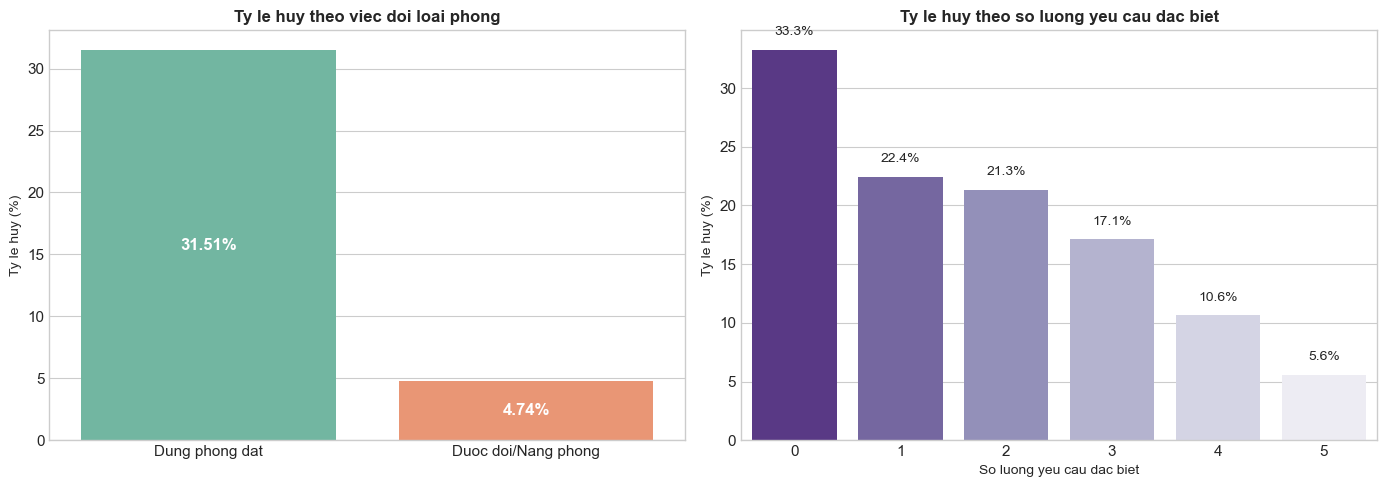

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_change_cancel = df.groupby('is_room_changed')['is_canceled'].agg(
    Cancel_Rate=lambda x: x.mean() * 100
).reset_index()
room_change_cancel['Label'] = room_change_cancel['is_room_changed'].map({0: 'Dung phong dat', 1: 'Duoc doi/Nang phong'})

sns.barplot(data=room_change_cancel, x='Label', y='Cancel_Rate', palette='Set2', ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha='center', va='center', fontsize=12, color='white', fontweight='bold')
axes[0].set_title('Ty le huy theo viec doi loai phong', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Ty le huy (%)', fontsize=10)

requests_cancel = df.groupby('total_of_special_requests')['is_canceled'].agg(
    Cancel_Rate=lambda x: x.mean() * 100,
    Count='count'
).reset_index()

sns.barplot(data=requests_cancel, x='total_of_special_requests', y='Cancel_Rate', palette='Purples_r', ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha='center', va='bottom', fontsize=10)
axes[1].set_title('Ty le huy theo so luong yeu cau dac biet', fontsize=12, fontweight='bold')
axes[1].set_xlabel('So luong yeu cau dac biet', fontsize=10)
axes[1].set_ylabel('Ty le huy (%)', fontsize=10)

plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Khách được chuyển đổi phòng (chủ yếu là nâng hạng phòng khi check-in hoặc có sự sắp xếp linh hoạt) có tỷ lệ hủy cực kỳ thấp (~4.7%) so với khách không đổi phòng (~30.5%).
- Khách có càng nhiều yêu cầu đặc biệt (từ 1 đến 5 yêu cầu) thì tỷ lệ hủy càng giảm mạnh (từ 38% xuống dưới 10%). Điều này cho thấy những khách hàng có tương tác, gửi yêu cầu dịch vụ cụ thể là những khách hàng có cam kết cao và thực sự có nhu cầu lưu trú.

### Giai phap va Khuyen nghi chien luoc doi voi van de Huy phong (Cancellation Strategies)

1. **Quan ly don dat truoc co Lead Time dai (>60 ngay):**
   - Trien khai he thong email tu dong (Re-engagement CRM) nhac nho lich trinh, xac nhan dat phong va gioi thieu cac dich vu tien ich (dua don san bay, spa, tour trai nghiem) truoc ngay check-in 30 ngay va 7 ngay.
   - Ap dung chinh sach uu dai khi khach xac nhan thanh toan truoc mot phan chi phi de giam rui ro huy phong gio chot.

2. **Dieu chinh chinh sach dat coc va kenh OTA:**
   - Ra soat hop dong voi cac cong ty du lich va dai ly doan (Groups); yeu cau tien coc linh hoat theo tung giai doan (staggered deposits) thay vi don thuan gan nhan Non-refundable gay hieu ung huy hang loat.
   - Thiet lap chinh sach huy phong theo bac thang (vi du: mien phi truoc 7 ngay, tinh phi 50% neu huy trong vong 3-6 ngay, 100% neu huy trong vong 48h).

3. **Gia tang tuong tac va ca nhan hoa dich vu som:**
   - Khuyen khich khach hang lua chon cac yeu cau dac biet (chon huong phong, loai giuong, yeu cau gio check-in som) ngay tren form dat phong hoac email xac nhan vi khach co yeu cau dac biet co ty le huy phong thap hon den 70%.

4. **Mo hinh Overbooking thong minh:**
   - Xay dung ty le nhan dat phong vuot muc (Overbooking limit) dua tren Lead Time va kenh phan phoi. Doi voi City Hotel vao mua cao diem co the ap dung muc overbooking tu 8-12% de toi uu cong suat phong.

## 3. Phan tich Gia phong trung binh (ADR) va Doanh thu (Pricing & Revenue Analysis)

ADR (Average Daily Rate) va Doanh thu la hai chi so cot loi danh gia hieu qua kinh doanh va nang luc khai thac tai san cua khach san.

### Cau hoi 6: Xu huong bien dong ADR va luong khach theo thang giua City Hotel va Resort Hotel nhu the nao?

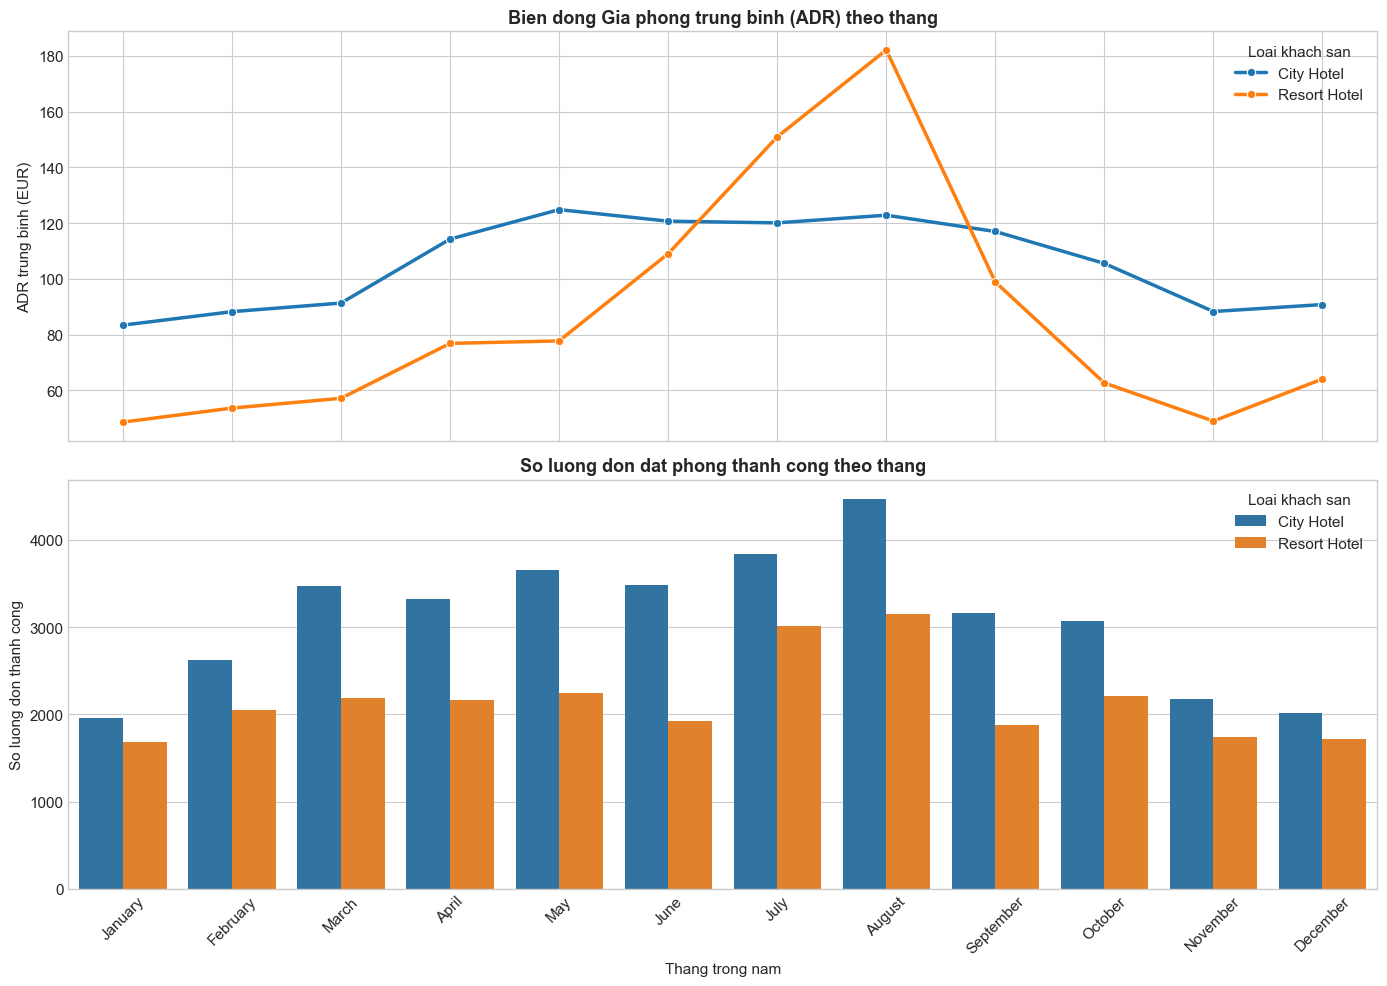

In [8]:
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_hotel = df[df['is_canceled'] == 0].groupby(['arrival_date_month', 'hotel'], observed=False).agg(
    Avg_ADR=('adr', 'mean'),
    Total_Guests=('total_guests', 'sum'),
    Bookings_Count=('hotel', 'count')
).reset_index()

monthly_hotel['arrival_date_month'] = pd.Categorical(monthly_hotel['arrival_date_month'], categories=months_order, ordered=True)
monthly_hotel = monthly_hotel.sort_values('arrival_date_month')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.lineplot(
    data=monthly_hotel,
    x='arrival_date_month',
    y='Avg_ADR',
    hue='hotel',
    marker='o',
    palette=['#1f77b4', '#ff7f0e'],
    linewidth=2.5,
    ax=axes[0]
)
axes[0].set_title('Bien dong Gia phong trung binh (ADR) theo thang', fontsize=13, fontweight='bold')
axes[0].set_ylabel('ADR trung binh (EUR)', fontsize=11)
axes[0].legend(title='Loai khach san')

sns.barplot(
    data=monthly_hotel,
    x='arrival_date_month',
    y='Bookings_Count',
    hue='hotel',
    palette=['#1f77b4', '#ff7f0e'],
    ax=axes[1]
)
axes[1].set_title('So luong don dat phong thanh cong theo thang', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Thang trong nam', fontsize=11)
axes[1].set_ylabel('So luong don thanh cong', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Loai khach san')

plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Resort Hotel co tinh bien dong mua vu cuc ky ro ret: ADR tang vot vao thang 7 va thang 8 (dat tren 180 EUR/dem) do la cao diem du lich he cua chau Au. Trong cac thang mua dong (thang 11 den thang 2), ADR giam xuong duoi 60 EUR/dem.
- City Hotel duy tri muc gia va luong khach on dinh hon xuyen suot nam, voi muc ADR dao dong trong khoang 90 - 120 EUR/dem, dat dinh nhe vao thang 5, 6, 9, 10 (cac mua hoi nghi, du lich thanh pho va su kien cong tac).

### Cau hoi 7: Hieu qua doanh thu theo loai phong (Room Type) va loai khach hang (Customer Type)

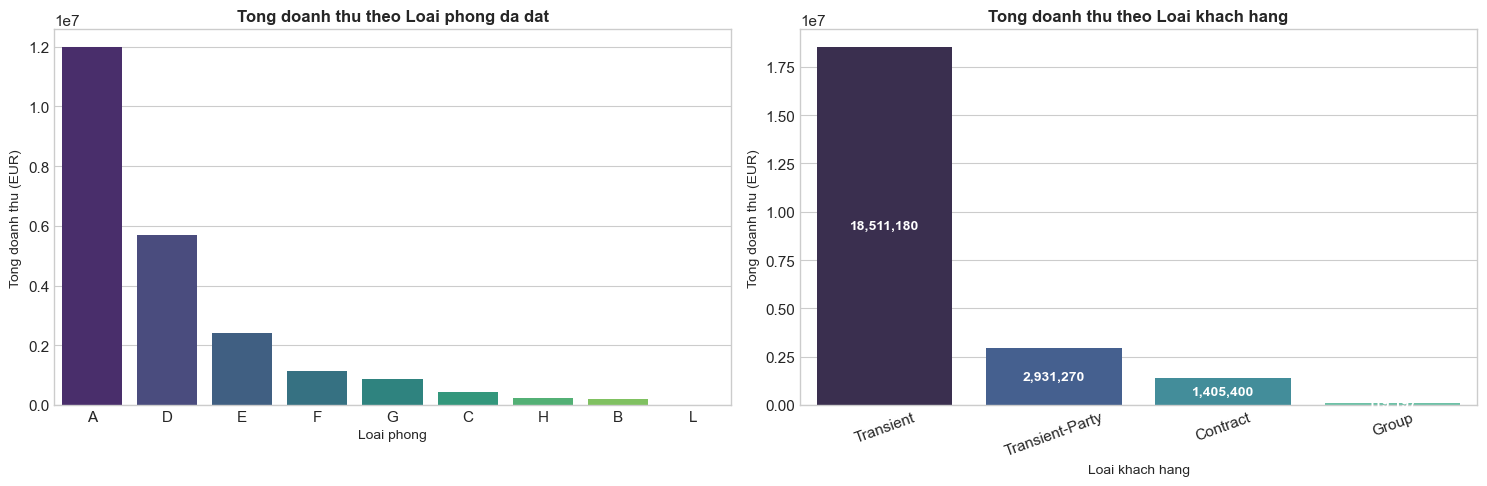

In [9]:
room_revenue = df[df['is_canceled'] == 0].groupby('reserved_room_type').agg(
    Avg_ADR=('adr', 'mean'),
    Total_Revenue=('total_revenue', 'sum'),
    Bookings=('reserved_room_type', 'count')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

cust_revenue = df[df['is_canceled'] == 0].groupby('customer_type').agg(
    Avg_ADR=('adr', 'mean'),
    Total_Revenue=('total_revenue', 'sum'),
    Bookings=('customer_type', 'count')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=room_revenue, x='reserved_room_type', y='Total_Revenue', palette='viridis', ax=axes[0])
axes[0].set_title('Tong doanh thu theo Loai phong da dat', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loai phong', fontsize=10)
axes[0].set_ylabel('Tong doanh thu (EUR)', fontsize=10)

sns.barplot(data=cust_revenue, x='customer_type', y='Total_Revenue', palette='mako', ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha='center', va='center', fontsize=10, color='white', fontweight='bold')
axes[1].set_title('Tong doanh thu theo Loai khach hang', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loai khach hang', fontsize=10)
axes[1].set_ylabel('Tong doanh thu (EUR)', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Phong loai A va loai D mang lai ty trong doanh thu cao nhat cho ca hai khach san do so luong phong doi dao va phu hop voi da so khach le.
- Khach hang loai 'Transient' (khach vang lai/khach le) la dong luc doanh thu chu luc, dong gop tren 80% tong doanh thu toan he thong, theo sau la 'Transient-Party'.

### Cau hoi 8: Kenh phan phoi (Distribution Channel) nao tao ra doanh thu va ADR cao nhat?

,distribution_channel,Bookings,Avg_ADR,Total_Revenue,Avg_Stay
3,TA/TO,47628,104.11,18210736.66,3.70
1,Direct,11030,107.77,4038679.62,3.06
0,Corporate,4416,67.32,686852.81,2.25
2,GDS,145,119.73,30779.36,1.70


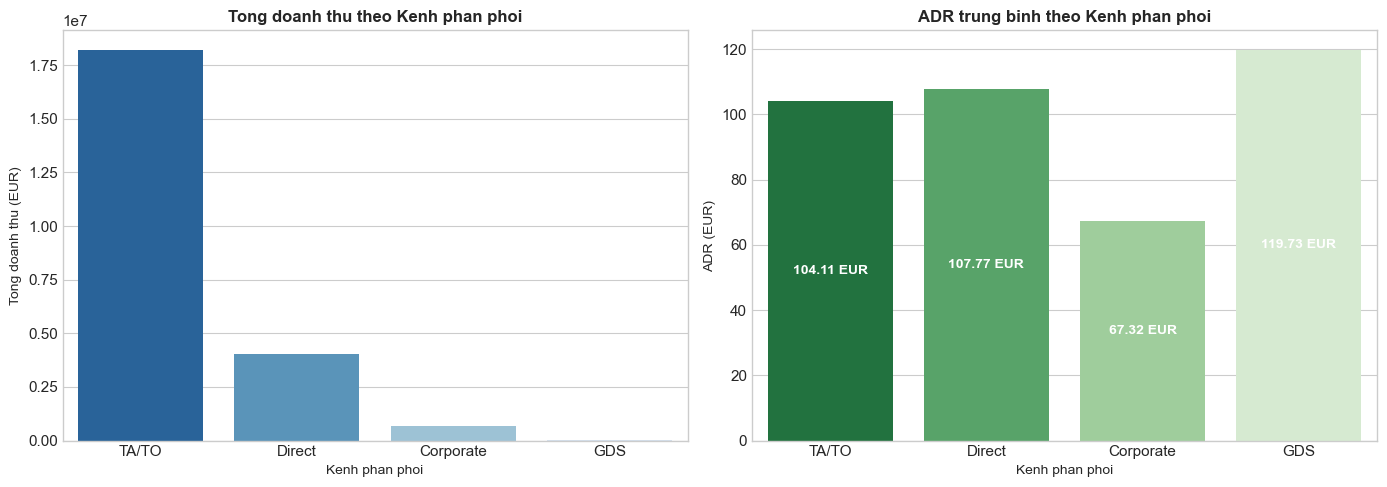

In [10]:
channel_perf = df[df['is_canceled'] == 0].groupby('distribution_channel').agg(
    Bookings=('distribution_channel', 'count'),
    Avg_ADR=('adr', 'mean'),
    Total_Revenue=('total_revenue', 'sum'),
    Avg_Stay=('total_stay', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

display(channel_perf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=channel_perf, x='distribution_channel', y='Total_Revenue', palette='Blues_r', ax=axes[0])
axes[0].set_title('Tong doanh thu theo Kenh phan phoi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kenh phan phoi', fontsize=10)
axes[0].set_ylabel('Tong doanh thu (EUR)', fontsize=10)

sns.barplot(data=channel_perf, x='distribution_channel', y='Avg_ADR', palette='Greens_r', ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f} EUR", (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha='center', va='center', fontsize=10, color='white', fontweight='bold')
axes[1].set_title('ADR trung binh theo Kenh phan phoi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kenh phan phoi', fontsize=10)
axes[1].set_ylabel('ADR (EUR)', fontsize=10)

plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Kênh 'TA/TO' mang lai tong doanh thu tuyet doi cao nhat do quy mo luong dat phong lon.
- Tuy nhien, kenh 'Direct' (dat truc tiep) va 'Corporate' mang lai muc ADR rat tot va dac biet khong phai tra phi hoa hong cao (15-25%) cho cac san OTA.

### Giai phap va Khuyen nghi Toi uu Doanh thu va Chien luoc Gia (Revenue Management Strategies)

1. **Chien luoc Dinh gia Dong (Dynamic Pricing theo mua vu):**
   - Doi voi Resort Hotel: Toi uu hoa gia ban o muc cao nhat vao thang 7-8 bang cach dong goi goi dich vu (phong + am thuc + dich vu giai tri). Vao cac thang thap diem (thang 11 - thang 2), ap dung goi gia dac biet ket hop hoi thao, team building doanh nghiep hoac spa nghi duong dai ngay de nang cao cong suat phong.
   - Doi voi City Hotel: Duy tri muc gia linh hoat theo ngay trong tuan (weekday cho khach cong tac voi gia tot, weekend cho khach du lich ngan ngay).

2. **Day manh Chien luoc Dat phong Truc tiep (Direct Booking Incentive):**
   - Xay dung chuong trinh thanh vien (Loyalty Program) voi uu dai: giam 5-10% gia phong truc tiep tren website, tang voucher am thuc / spa, mien phi nang hang phong khi con phong trong (free upgrade).
   - Dieu nay giup tiet kiem chi phi hoa hong kenh OTA va gia tang ty le khach hang trung thanh.

3. **Chien luoc Upselling & Cross-selling phong cao cap:**
   - Cac phong hang cao (Suite, Family Room) co ADR vuot troi. Khach san nen chu dong thuc hien upsell qua email truoc ngay check-in voi muc phi nang hang uu dai de giai phong cac phong tieu chuan (Room A) cho khach moi.

## 4. Phan tich Chan dung va Hanh vi Khach hang (Customer Behavioral Analysis)

Thau hieu nguon goc, co cau nhom khach va thoi gian luu tru giup ca nhan hoa dich vu va toi uu hoa chien dich tiep thi.

### Cau hoi 9: Khach hang den tu nhung quoc gia nao nhieu nhat (Top Nationalities)?

,Country,Successful_Bookings,Percentage
0,PRT,17572,33.93
1,GBR,8439,16.29
2,FRA,7091,13.69
3,ESP,5382,10.39
4,DEU,4332,8.36
5,IRL,2347,4.53
6,ITA,1986,3.83
7,BEL,1670,3.22
8,NLD,1560,3.01
9,USA,1412,2.73


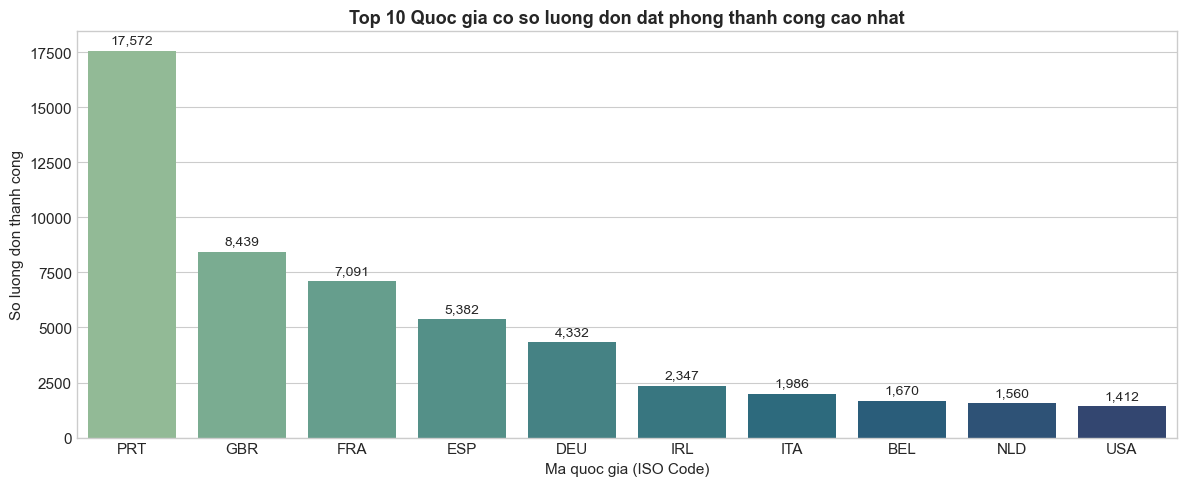

In [11]:
top_countries = df[df['is_canceled'] == 0]['country'].value_counts().head(10).reset_index()
top_countries.columns = ['Country', 'Successful_Bookings']
top_countries['Percentage'] = (top_countries['Successful_Bookings'] / top_countries['Successful_Bookings'].sum()) * 100

display(top_countries)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top_countries, x='Country', y='Successful_Bookings', palette='crest')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height() + 200), ha='center', va='bottom', fontsize=10)

plt.title('Top 10 Quoc gia co so luong don dat phong thanh cong cao nhat', fontsize=13, fontweight='bold')
plt.xlabel('Ma quoc gia (ISO Code)', fontsize=11)
plt.ylabel('So luong don thanh cong', fontsize=11)
plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Portugal (PRT - Bo Dao Nha) la thi truong noi dia chiem ty trong lon nhat.
- Cac thi truong quoc te chu luc tiep theo deu thuoc Tay Au: Vuong quoc Anh (GBR), Phap (FRA), Tay Ban Nha (ESP), Duc (DEU), Y (ITA) va Ireland (IRL).
- Khach quoc te Tay Au thuong co chi tieu ADR cao hon va thoi gian luu tru dai ngay hon so voi khach noi dia.

### Cau hoi 10: Thoi gian luu tru (Length of Stay) va Co cau khach (Solo, Couple, Family) phan bo ra sao?

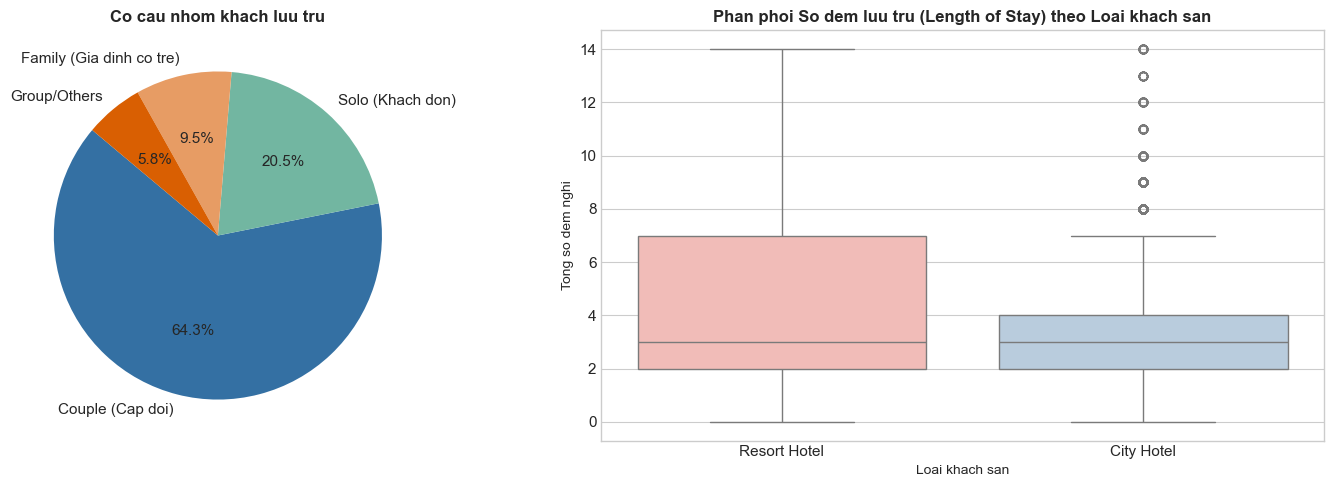

In [12]:
def categorize_party(row):
    if row['adults'] == 1 and row['children'] == 0 and row['babies'] == 0:
        return 'Solo (Khach don)'
    elif row['adults'] == 2 and row['children'] == 0 and row['babies'] == 0:
        return 'Couple (Cap doi)'
    elif (row['children'] > 0) or (row['babies'] > 0):
        return 'Family (Gia dinh co tre)'
    else:
        return 'Group/Others'

df['party_type'] = df.apply(categorize_party, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

party_counts = df[df['is_canceled'] == 0]['party_type'].value_counts()
party_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#3470a3', '#72b6a1', '#e79c64', '#d95f02'], ax=axes[0])
axes[0].set_title('Co cau nhom khach luu tru', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')

sns.boxplot(
    data=df[(df['is_canceled'] == 0) & (df['total_stay'] <= 14)],
    x='hotel',
    y='total_stay',
    palette='Pastel1',
    ax=axes[1]
)
axes[1].set_title('Phan phoi So dem luu tru (Length of Stay) theo Loai khach san', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loai khach san', fontsize=10)
axes[1].set_ylabel('Tong so dem nghi', fontsize=10)

plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Co cau khach: Cap doi (Couple - 2 nguoi lon) chiem ap dao voi tren 65% tong luong khach, tiep theo la khach di mot minh (Solo - ~22%) va khach gia dinh (Family - ~10%).
- Thoi gian luu tru: Khach City Hotel chu yeu luu tru ngan tu 1 - 3 dem (trung vi la 2 dem). Khach Resort Hotel co thoi gian luu tru dai hon ro ret, pho bien tu 3 - 7 dem.

### Cau hoi 11 & 12: Ty le khach quay lai (Repeated Guests) va Xu huong chon goi am thuc (Meal Preferences)

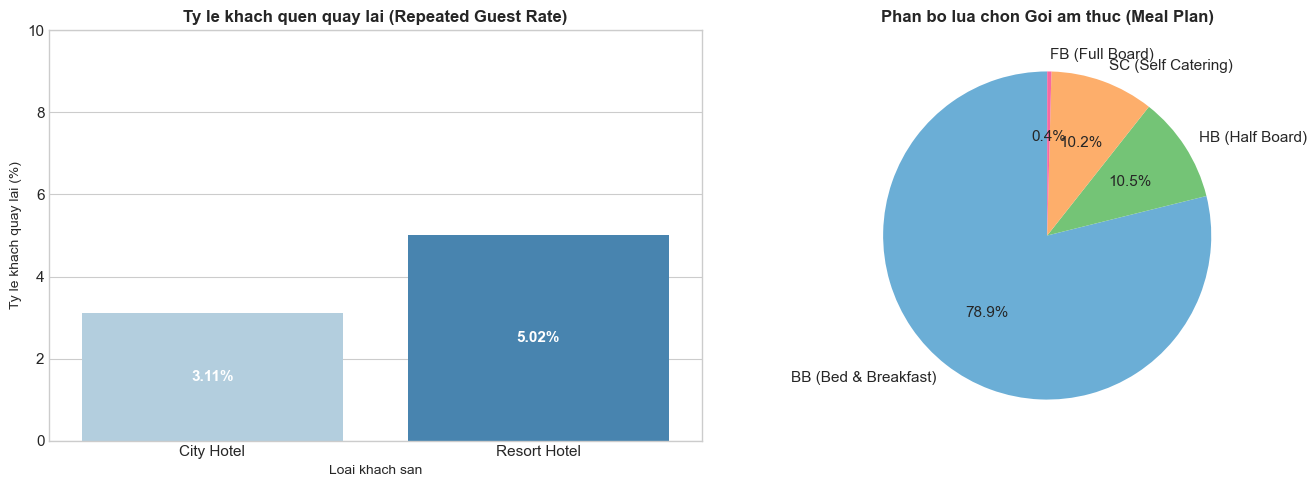

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

repeat_summary = df.groupby('hotel')['is_repeated_guest'].agg(
    Repeat_Rate=lambda x: x.mean() * 100
).reset_index()

sns.barplot(data=repeat_summary, x='hotel', y='Repeat_Rate', palette='Blues', ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha='center', va='center', fontsize=11, color='white', fontweight='bold')
axes[0].set_title('Ty le khach quen quay lai (Repeated Guest Rate)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loai khach san', fontsize=10)
axes[0].set_ylabel('Ty le khach quay lai (%)', fontsize=10)
axes[0].set_ylim(0, 10)

meal_counts = df[df['is_canceled'] == 0]['meal'].value_counts()
meal_map_label = {'BB': 'BB (Bed & Breakfast)', 'HB': 'HB (Half Board)', 'SC': 'SC (Self Catering)', 'FB': 'FB (Full Board)'}
meal_counts.index = meal_counts.index.map(meal_map_label)
meal_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#6baed6', '#74c476', '#fdae6b', '#f768a1'], ax=axes[1])
axes[1].set_title('Phan bo lua chon Goi am thuc (Meal Plan)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Ket qua va Nhan xet kinh doanh:**
- Ty le khach quay lai (Repeated Guest Rate) hien tai con rat thap (duoi 4% o ca hai khach san). Dieu nay cho thay khach san chua khai thac tot tiem nang giu chan khach hang va chuong trinh khach hang than thiet con so khai.
- Goi am thuc: 'BB' (Giuong ngu va bua sang) chiem tuyet doi tren 77% thi phan, theo sau la 'HB' va 'SC'. Goi 'FB' (Phuc vu tron goi ca 3 bua) chiem ty le rat nho (<1%).

### Giai phap va Khuyen nghi Ca nhan hoa Trai nghiem va Giu chan Khach hang (Customer Retention Strategies)

1. **Thiet lap Chien dich Marketing theo Quoc gia muc tieu:**
   - Tap trung ngan sach quang cao so tai cac thi truong Tay Au (GBR, FRA, DEU, ESP) vao quy 1 va quy 2 de don dau mua du lich he tai Resort Hotel.
   - Da dang hoa ngon ngu giao tiep tren website, tai lieu huong dan va nhan vien le tan theo cac ngon ngu chinh (Anh, Phap, Duc, Tay Ban Nha).

2. **Chien luoc phuc vu cho phan khuc Cap doi (Couples) va Gia dinh (Families):**
   - Goi Cap doi: Thiet ke cac combo nghi duong lang man bao gom bua toi kem ruou vang, dich vu spa va tour ngam hoang hon.
   - Goi Gia dinh: Cung cap dich vu giu tre, khu vui choi tre em, giuong phu mien phi va thuc don rieng cho tre nho de nang cao su hai long cua phan khuc co muc chi tieu cao nay.

3. **Gia tang Ty le Khach quay lai (Loyalty & Retention):**
   - Gui khao sat danh gia chat luong va ma giam gia tri an 15% cho lan dat phong tiep theo trong vong 48h sau khi khach check-out.
   - Luu tru ho so so thich cua khach (vi du: loai phong yeu thich, thoi gian check-in thuong xuyen) de ca nhan hoa trai nghiem khi khach quay tro lai.

## 5. Tong ket Chien luoc Kinh doanh Tong the (Executive Summary & Action Plan)

| Linh vuc trong tam | Phat hien chinh | Hanh dong chien luoc | Chi so do luong (KPIs) |
| :--- | :--- | :--- | :--- |
| **Kiem soat Huy phong** | Ty le huy tong the 27.5%; Lead time dai (>90 ngay) va nhom khach doan co rui ro huy rat cao (>40-60%). | Tu dong hoa email xac nhan som, ap dung coc theo tien do va chinh sach huy bac thang linh hoat. | Giam ty le huy phong xuong duoi 20%. |
| **Quan ly Doanh thu (ADR)** | Resort bien dong manh theo mua he (ADR dat dinh >180 EUR); City on dinh quanh 100 EUR. | Dinh gia dong (Dynamic Pricing), ket hop hop dong hoi nghi mua thap diem cho Resort va day manh Direct Booking de giam hoa hong OTA. | Tang RevPAR them 10-15% trong nam toi. |
| **Phat trien Khach hang** | Khach quoc te Tay Au chiem da so; Cap doi chiem >65%; Ty le khach quay lai con thap (<4%). | Chay marketing tap trung vao Tay Au; phat trien goi combo cho Cap doi & Gia dinh; xay dung Loyalty Program. | Tang ty le khach quay lai tu <4% len tren 10%. |